# 05 - Feature-based models

**Appliance energy forecasting**

**Inputs**

```text
data/processed/appliance_hourly.csv
outputs/metrics/benchmark_mase_scale.csv
outputs/metrics/benchmark_metrics_rolling.csv
outputs/metrics/sarimax_metrics_rolling.csv
outputs/forecasts/benchmark_forecasts_rolling.csv
```

**Outputs produced**

```text
outputs/forecasts/feature_forecasts_rolling.csv
outputs/metrics/feature_metrics_rolling.csv
outputs/metrics/feature_cv_results.csv
outputs/metrics/feature_importance.csv
outputs/figures/05_*.png
```

## 1. Setup

In [23]:

# 1. Imports


import warnings
warnings.filterwarnings("ignore")

import time

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 130)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [24]:
# ------------------------------------------------------------
# 2. Configuration
# ------------------------------------------------------------

def find_project_root(markers=("data/raw", "data/processed", "notebooks"), start=None):
    """
    Locate the project root by walking up from the working directory.

    The root is the first ancestor containing any of `markers`, so this works on
    a fresh setup (before data/processed exists) as well as later, and does not
    depend on the notebook folder having a particular name.
    """

    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate

    raise FileNotFoundError(
        f"No project root found from {start} upwards.\n"
        f"Looked for: {markers}\n"
        "Expected layout:  <project>/notebooks/*.ipynb  and  <project>/data/raw/"
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

FORECAST_DIR = OUTPUT_DIR / "forecasts"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

for path in [FORECAST_DIR, METRICS_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
rng = np.random.default_rng(RANDOM_STATE)

TARGET = "Appliances"

HORIZON = 24
TEST_STEPS = 14 * 24
N_WINDOWS = TEST_STEPS // HORIZON

# Feature specification
LAGS = [1, 2, 3, 6, 12, 24, 25, 48, 168]
ROLLING_WINDOWS = [3, 6, 24, 168]

INDOOR_TEMP_COLS = [f"T{i}" for i in range(1, 10)]
INDOOR_HUM_COLS = [f"RH_{i}" for i in range(1, 10)]
WEATHER_COLS = ["T_out", "Press_mm_hg", "RH_out", "Windspeed", "Visibility", "Tdewpoint"]


def save_fig(fig, name, figure_dir=FIGURE_DIR):
    """Save a figure to outputs/figures and report the path."""

    path = figure_dir / name

    fig.savefig(path, dpi=200, bbox_inches="tight")

    print("Saved figure:", path)

    return path


print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cjfin\Desktop\assignment 2


In [25]:
# 3. Load data and the settings 


data = pd.read_csv(
    PROCESSED_DIR / "appliance_hourly.csv",
    index_col=0,
    parse_dates=True,
).asfreq("h")

y = data[TARGET]

train = y.iloc[:-TEST_STEPS]
test = y.iloc[-TEST_STEPS:]

SCALE = float(
    pd.read_csv(METRICS_DIR / "benchmark_mase_scale.csv", index_col=0).loc["mase_scale", "value"]
)

benchmark_metrics = pd.read_csv(METRICS_DIR / "benchmark_metrics_rolling.csv")
sarimax_metrics = pd.read_csv(METRICS_DIR / "sarimax_metrics_rolling.csv")

BEST_BENCHMARK = benchmark_metrics.iloc[0]["model"]
BEST_BENCHMARK_MASE = float(benchmark_metrics.iloc[0]["MASE"])
BEST_SARIMAX_MASE = float(sarimax_metrics["MASE"].min())

print("Train:", len(train), "| Test:", len(test))
print("MASE scale:", round(SCALE, 3))
print(f"Bar to clear: {BEST_BENCHMARK} at MASE {BEST_BENCHMARK_MASE:.3f}, "
      f"best SARIMAX at MASE {BEST_SARIMAX_MASE:.3f}")


def evaluate_forecast(name, y_true, y_pred, scale=None):
    """MAE, RMSE, MASE and Bias - identical to notebooks 03 and 04."""

    scale = SCALE if scale is None else scale

    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).reindex(y_true.index).astype(float)

    valid = y_true.notna() & y_pred.notna()

    errors = y_pred[valid] - y_true[valid]

    return {
        "model": name,
        "n": int(valid.sum()),
        "MAE": float(np.mean(np.abs(errors))),
        "RMSE": float(np.sqrt(np.mean(errors ** 2))),
        "MASE": float(np.mean(np.abs(errors)) / scale),
        "Bias": float(np.mean(errors)),
    }

Train: 2953 | Test: 336
MASE scale: 53.359
Bar to clear: seasonal_naive_weekly at MASE 0.804, best SARIMAX at MASE 0.689


## 2. The problem a feature-based model actually faces

SARIMAX produces a 24-hour forecast natively. A regression model does not: it predicts one
row of a feature table, and the features it wants most - the most recent values of the
target - are unavailable for most of the horizon.

At the forecast origin (17:00), predicting 18:00 gives a `lag_1` of the 17:00 reading,
which is known. Predicting 17:00 *the next day* would need a `lag_1` of 16:00 the next
day, which is 23 hours in the future and unknown. **A feature table built with `lag_1` and
evaluated on the whole test set is not a 24-hour forecast; it is twenty-four separate
one-hour-ahead forecasts.**

This is the single most important design decision in this notebook, and the one the
supplied demo pipeline gets wrong: it builds features including `lag_1`, fits on the
training rows, and predicts the whole test period using the *realised* test-set lags. Its
feature model therefore competes against SARIMAX and the benchmarks on an unequal footing.
Section 8 measures exactly how much that is worth.

### The three legitimate strategies

| Strategy | How it works | Cost |
|---|---|---|
| **Restricted single model** | One model using only features available 24 hours ahead: lags of 24 or more, rolling statistics shifted by 24 | Simplest and fastest, but throws away recent information even at step 1 |
| **Direct multi-horizon** | Twenty-four models, one per step $h$, each using only lags of $h$ or more | Each step uses the most recent information legitimately available; 24 fits to train |
| **Recursive** | One model with `lag_1`, applied 24 times, feeding its own predictions back in as lags | Uses all features, but errors compound across the horizon |

All three are implemented and compared, because which one wins is itself a result.

### Why lag features do not leak

For a target time $t$ at step $h$ from origin $o = t - h$, a feature with lag $\ell$ reads
$y_{t - \ell}$. Since $\ell \ge h$ by construction, $t - \ell \le t - h = o$, so every
feature value is at or before the origin. That is the invariant, and section 4 tests it
empirically rather than trusting the algebra.

## 3. Feature engineering

The feature table follows the brief: lagged target values, rolling means and standard
deviations, hour-of-day and day-of-week features, a weekend indicator, and optionally the
indoor sensor and outdoor weather variables.

One extra feature is included: the mean of the same hour over the previous seven days.
This is a *seasonal* rolling mean, the natural hourly analogue of the rolling means the
brief asks for, and it encodes the structure notebook 02 identified - a stable daily shape
with volatile amplitude. A tree ensemble would need many splits to reconstruct it from raw
lags, so supplying it explicitly is reasonable feature engineering.

The `min_lag` argument is what makes the table honest. Every target-derived feature is
shifted by at least `min_lag` hours, so setting `min_lag = h` produces a table valid for
forecasting $h$ steps ahead.

In [26]:

# 4. Feature construction

def make_calendar_features(index):
    """
    Deterministic functions of the timestamp.

    These are known arbitrarily far ahead, so they never constrain the horizon.
    """

    out = pd.DataFrame(index=index)

    out["hour"] = index.hour
    out["dayofweek"] = index.dayofweek
    out["is_weekend"] = (index.dayofweek >= 5).astype(int)

    out["hour_sin"] = np.sin(2 * np.pi * index.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * index.hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * index.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * index.dayofweek / 7)

    return out


def make_features(frame, min_lag=HORIZON, covariates="none", target=TARGET):
    """
    Build the supervised feature table.

    min_lag     the shortest lookback allowed. Every feature derived from the
                target is shifted by at least this many hours, so the table is
                valid for forecasting min_lag steps ahead.

    covariates  "none"      calendar and target-derived features only
                "lagged"    sensor and weather values from min_lag hours ago
                            (operational: available at the forecast origin)
                "realised"  sensor and weather values at the target time
                            (conditional: NOT available in a real forecast)
    """

    series = frame[target]

    out = make_calendar_features(frame.index)

    # Lagged target values, restricted to lags that respect the horizon.
    for lag in LAGS:
        if lag >= min_lag:
            out[f"lag_{lag}"] = series.shift(lag)

    # Rolling statistics, shifted before rolling so the window ends at the origin.
    for window in ROLLING_WINDOWS:
        shifted = series.shift(min_lag)

        out[f"roll_mean_{window}"] = shifted.rolling(window).mean()
        out[f"roll_std_{window}"] = shifted.rolling(window).std()

    # The strongest benchmark from notebook 03, supplied as a feature.
    same_hour = pd.concat([series.shift(24 * k) for k in range(1, 8)], axis=1)
    out["same_hour_mean_7d"] = same_hour.mean(axis=1)

    covariate_cols = [c for c in frame.columns if c != target]

    if covariates == "lagged":
        for col in covariate_cols:
            out[f"{col}_lag{min_lag}"] = frame[col].shift(min_lag)

    elif covariates == "realised":
        for col in covariate_cols:
            out[col] = frame[col]

    return out


features_h24 = make_features(data, min_lag=HORIZON)

print("Feature table for a 24-hour horizon:", features_h24.shape)
print("\nFeatures:", list(features_h24.columns))
print("\nRows lost to the longest lookback:", int(features_h24.isna().any(axis=1).sum()))

features_h24.head(3).round(2)

Feature table for a 24-hour horizon: (3289, 20)

Features: ['hour', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_24', 'lag_25', 'lag_48', 'lag_168', 'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_24', 'roll_std_24', 'roll_mean_168', 'roll_std_168', 'same_hour_mean_7d']

Rows lost to the longest lookback: 191


,hour,dayofweek,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_24,lag_25,lag_48,lag_168,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_24,roll_std_24,roll_mean_168,roll_std_168,same_hour_mean_7d
date,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,17,0,0,-0.97,-0.26,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 18:00:00,18,0,0,-1.00,-0.00,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 19:00:00,19,0,0,-0.97,0.26,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:

# 5. Leakage test: features must not react to the future

def assert_no_future_information(frame, min_lag, timestamp, target=TARGET):
    """
    Empirical leakage check.

    Corrupt every target value strictly after the forecast origin, rebuild the
    features, and confirm the feature row for `timestamp` is unchanged. If any
    feature reads a value from after the origin, this fails.
    """

    origin = timestamp - pd.Timedelta(hours=min_lag)

    corrupted = frame.copy()
    corrupted.loc[corrupted.index > origin, target] += 10_000.0

    original_row = make_features(frame, min_lag=min_lag).loc[timestamp]
    corrupted_row = make_features(corrupted, min_lag=min_lag).loc[timestamp]

    differing = original_row.index[
        ~np.isclose(original_row.values.astype(float),
                    corrupted_row.values.astype(float),
                    equal_nan=True)
    ]

    assert len(differing) == 0, f"Features using future values: {list(differing)}"

    return origin


# Test at several horizons and several timestamps.
for min_lag in [1, 6, 24]:
    for timestamp in [test.index[0], test.index[100], test.index[-1]]:
        origin = assert_no_future_information(data, min_lag, timestamp)

print("Leakage tests passed for min_lag in {1, 6, 24}.")
print("Every feature value is drawn from at or before the forecast origin.")
print("\nThis is the basis of tests/test_features.py.")

Leakage tests passed for min_lag in {1, 6, 24}.
Every feature value is drawn from at or before the forecast origin.

This is the basis of tests/test_features.py.


This test is worth keeping in the repository. It catches the classic mistake - computing a
rolling mean without shifting first - which is invisible in the feature table but produces
suspiciously good results. The README lists it as a required test, and the assertion above
is the implementation.

## 4. Model and hyperparameters

HistGradientBoostingRegressor was used. Hyperparameters are chosen by **expanding-window cross-validation
on the training data only**: each fold trains on everything up to a cut point and validates
on the following 14 days, mimicking the way the model will actually be used. Ordinary
k-fold cross-validation would be wrong here, because it would train on data from after the
validation period.

In [28]:

# 6. The estimator

def make_model(learning_rate=0.03, max_depth=6, n_estimators=600, random_state=RANDOM_STATE):
    return HistGradientBoostingRegressor(
        max_iter=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=random_state,
    )


def fit_model(features, target_series, end=None, **kwargs):
    """Fit on complete feature rows up to `end` (exclusive)."""

    usable = features.notna().all(axis=1) & target_series.notna()

    X = features[usable]
    y_fit = target_series[usable]

    if end is not None:
        X = X[X.index < end]
        y_fit = y_fit[y_fit.index < end]

    model = make_model(**kwargs)
    model.fit(X, y_fit)

    return model


print("Estimator:", type(make_model()).__name__)

Estimator: HistGradientBoostingRegressor


In [29]:

# 7. Expanding-window cross-validation on the training data

CV_CACHE = METRICS_DIR / "feature_cv_results.csv"

PARAM_GRID = [
    {"learning_rate": 0.03, "max_depth": 4, "n_estimators": 600},
    {"learning_rate": 0.03, "max_depth": 6, "n_estimators": 600},
    {"learning_rate": 0.03, "max_depth": 8, "n_estimators": 600},
    {"learning_rate": 0.10, "max_depth": 4, "n_estimators": 300},
    {"learning_rate": 0.10, "max_depth": 6, "n_estimators": 300},
    {"learning_rate": 0.01, "max_depth": 6, "n_estimators": 1200},
]


def expanding_window_cv(features, target_series, params, n_folds=3, fold_length=14 * 24):
    """
    Expanding-window cross-validation.

    Fold k trains on everything before its validation block and validates on the
    next `fold_length` hours. Only training-period data is ever used.
    """

    train_end = target_series.index[-TEST_STEPS]

    maes = []

    for fold in range(n_folds, 0, -1):
        valid_start = train_end - pd.Timedelta(hours=fold_length * fold)
        valid_end = valid_start + pd.Timedelta(hours=fold_length)

        model = fit_model(features, target_series, end=valid_start, **params)

        block = features.loc[valid_start:valid_end].dropna()

        predictions = model.predict(block)

        maes.append(float(np.mean(np.abs(predictions - target_series.loc[block.index]))))

    return maes


if CV_CACHE.exists():
    cv_results = pd.read_csv(CV_CACHE)
    print("Loaded cached cross-validation results.")
else:
    rows = []

    started = time.time()

    for params in PARAM_GRID:
        maes = expanding_window_cv(features_h24, y, params)

        rows.append({**params, "mean_MAE": float(np.mean(maes)),
                     "fold_MAEs": np.round(maes, 2).tolist()})

    cv_results = pd.DataFrame(rows).sort_values("mean_MAE").reset_index(drop=True)
    cv_results.to_csv(CV_CACHE, index=False)

    print(f"Cross-validation complete in {time.time() - started:.0f}s")

print()
print(cv_results.round(3).to_string(index=False))

BEST_PARAMS = {
    k: v for k, v in cv_results.iloc[0].items()
    if k in {"learning_rate", "max_depth", "n_estimators"}
}

BEST_PARAMS["max_depth"] = int(BEST_PARAMS["max_depth"])
BEST_PARAMS["n_estimators"] = int(BEST_PARAMS["n_estimators"])

print("\nSelected hyperparameters:", BEST_PARAMS)
print("Spread of mean MAE across the grid:",
      round(cv_results["mean_MAE"].max() - cv_results["mean_MAE"].min(), 2), "Wh")

Loaded cached cross-validation results.

 learning_rate  max_depth  n_estimators  mean_MAE             fold_MAEs
          0.01          6          1200    44.946 [50.76, 37.65, 46.43]
          0.03          8           600    45.061 [50.58, 36.98, 47.62]
          0.03          6           600    45.827  [52.1, 38.44, 46.94]
          0.03          4           600    46.863  [55.28, 39.8, 45.51]
          0.10          6           300    47.105 [54.26, 39.51, 47.55]
          0.10          4           300    47.312 [55.55, 40.43, 45.96]

Selected hyperparameters: {'learning_rate': np.float64(0.01), 'max_depth': 6, 'n_estimators': 1200}
Spread of mean MAE across the grid: 2.37 Wh


Note the spread across the grid, and compare it later with the spread across *strategies*
in section 10. The folds also disagree with each other substantially, which is a warning
that with roughly seventeen weeks of training data a three-fold expanding-window selection
is noisy. Section 10 includes a sensitivity check on exactly this point.

## 5. Strategy A - one restricted model

The simplest honest approach: a single model whose features are all at least 24 hours old,
applied to every step of the horizon. It is trained once on the training data, and the
features for each test row use only observations from at or before that row's origin.

In [30]:

# 8. Restricted single model

forecasts = {}

started = time.time()

model_h24 = fit_model(features_h24, y, end=test.index[0], **BEST_PARAMS)

forecasts["feature_restricted_24"] = pd.Series(
    model_h24.predict(features_h24.loc[test.index]),
    index=test.index,
)

print(f"Fitted in {time.time() - started:.1f}s")
print(evaluate_forecast("feature_restricted_24", test, forecasts["feature_restricted_24"]))

Fitted in 2.8s
{'model': 'feature_restricted_24', 'n': 336, 'MAE': 38.55793195223329, 'RMSE': 65.75604074036733, 'MASE': 0.7226142878318363, 'Bias': -4.368906247546774}


## 6. Strategy B - direct multi-horizon

Twenty-four separate models, one per step of the horizon. Step 1 may use `lag_1`; step 12
may use lags of 12 or more; step 24 is restricted to lags of 24 or more. Each model is
applied only to the rows at its own step within each window.

This is more work to train, but it uses the most recent information that is legitimately
available at every point of the horizon.

In [31]:

# 9. Direct multi-horizon models

def direct_multihorizon_forecast(frame, y_series, test_index, horizon=HORIZON,
                                 covariates="none", params=None):
    """
    Fit one model per step of the horizon.

    The model for step h is trained on a feature table with min_lag = h, and used
    only for the rows that sit h steps after a forecast origin.
    """

    params = BEST_PARAMS if params is None else params

    n_windows = len(test_index) // horizon

    pieces = []

    for step in range(1, horizon + 1):
        step_features = make_features(frame, min_lag=step, covariates=covariates)

        model = fit_model(step_features, y_series, end=test_index[0], **params)

        step_index = pd.DatetimeIndex([
            test_index[window * horizon + step - 1] for window in range(n_windows)
        ])

        pieces.append(pd.Series(
            model.predict(step_features.loc[step_index]),
            index=step_index,
        ))

    return pd.concat(pieces).sort_index()


started = time.time()

forecasts["feature_direct"] = direct_multihorizon_forecast(data, y, test.index)

print(f"Fitted {HORIZON} models in {time.time() - started:.0f}s")
print(evaluate_forecast("feature_direct", test, forecasts["feature_direct"]))

Fitted 24 models in 63s
{'model': 'feature_direct', 'n': 336, 'MAE': 38.58462148885768, 'RMSE': 65.27228117241404, 'MASE': 0.7231144764966301, 'Bias': -3.947367318175815}


## 7. Strategy C - recursive

A single one-step-ahead model applied twenty-four times. After each step its own prediction
is written into the history and the features are rebuilt, so `lag_1` at step 2 is the
model's prediction for step 1 rather than an observation.

This uses the full feature set, at the cost of compounding its own errors across the
horizon. Crucially, no actual test observation from inside a window is ever used.

In [32]:

# 10. Recursive forecasting

def recursive_forecast(frame, y_series, test_index, model, horizon=HORIZON,
                       covariates="none", target=TARGET):
    """
    Iterate a one-step model across the horizon.

    Within a window, the target column is blanked from the window start onwards
    and refilled with the model's own predictions, so no observation from inside
    the window can reach the features.
    """

    n_windows = len(test_index) // horizon

    predictions = {}

    for window in range(n_windows):
        window_index = test_index[window * horizon:(window + 1) * horizon]

        working = frame.copy()

        # Everything from this window onwards is unknown at the forecast origin.
        working.loc[working.index >= window_index[0], target] = np.nan

        for timestamp in window_index:
            row = make_features(working, min_lag=1, covariates=covariates).loc[[timestamp]]

            prediction = float(model.predict(row)[0])

            working.loc[timestamp, target] = prediction

            predictions[timestamp] = prediction

    return pd.Series(predictions).sort_index()


started = time.time()

features_h1 = make_features(data, min_lag=1)

model_h1 = fit_model(features_h1, y, end=test.index[0], **BEST_PARAMS)

forecasts["feature_recursive"] = recursive_forecast(data, y, test.index, model_h1)

print(f"Recursive forecasts produced in {time.time() - started:.0f}s")
print(evaluate_forecast("feature_recursive", test, forecasts["feature_recursive"]))

Recursive forecasts produced in 15s
{'model': 'feature_recursive', 'n': 336, 'MAE': 37.483772258026434, 'RMSE': 61.08217675652225, 'MASE': 0.7024834586315428, 'Bias': 0.20756272849370255}


In [33]:

# 11. Confirm the recursive forecast used no future observations

# Re-run the first window with the whole test period corrupted. If any actual
# test observation reached the features, the forecast would change.
corrupted_data = data.copy()
corrupted_data.loc[test.index, TARGET] += 10_000.0

check_window = recursive_forecast(
    corrupted_data, y, test.index[:HORIZON], model_h1
)

assert np.allclose(
    check_window.values,
    forecasts["feature_recursive"].iloc[:HORIZON].values,
), "Recursive forecast changed when test observations were corrupted"

print("Recursive forecasts are unchanged when test observations are corrupted.")
print("No observation from inside a window reaches its own forecast.")

Recursive forecasts are unchanged when test observations are corrupted.
No observation from inside a window reaches its own forecast.


## 8. How much is one-hour-ahead forecasting worth?

The demo pipeline builds features including `lag_1` and predicts the whole test period from
the realised test-set lags. That model is answering an easier question: *what will the next
hour look like, given the last hour?* It is reported here purely as a diagnostic, clearly
labelled, and it must not be entered into the model comparison.

The gap between it and the recursive model is a direct measurement of the value of the most
recent observation - and of how much a badly specified evaluation can flatter a model.

In [34]:

# 12. One-hour-ahead diagnostic (NOT a 24-hour forecast)

diagnostic_1step = pd.Series(
    model_h1.predict(features_h1.loc[test.index]),
    index=test.index,
)

diagnostic_metrics = evaluate_forecast("DIAGNOSTIC_1step_ahead", test, diagnostic_1step)

print(diagnostic_metrics)

print(f"\nMASE, 1 hour ahead : {diagnostic_metrics['MASE']:.3f}")
print(f"MASE, 24 hours ahead (recursive, same model): "
      f"{evaluate_forecast('r', test, forecasts['feature_recursive'])['MASE']:.3f}")
print(f"MASE, best benchmark: {BEST_BENCHMARK_MASE:.3f}")

{'model': 'DIAGNOSTIC_1step_ahead', 'n': 336, 'MAE': 29.57626391084643, 'RMSE': 53.85005908054208, 'MASE': 0.5542888272415463, 'Bias': -2.0648454644129326}

MASE, 1 hour ahead : 0.554
MASE, 24 hours ahead (recursive, same model): 0.702
MASE, best benchmark: 0.804


The one-hour-ahead figure is dramatically better than anything else in the project. That is
not a modelling achievement; it is a different and much easier problem. Reporting it
alongside 24-hour forecasts would be the most serious methodological error available in
this assignment, and the report should say explicitly that the demo pipeline's feature
model number is not comparable with its SARIMAX and benchmark numbers.

## 9. Do sensor and weather covariates help?

Notebook 02 found weak covariate correlations that shrank further once hour-of-day was
removed; notebook 04 found the weather variables insignificant in SARIMAX. A tree ensemble
can use them non-linearly, so it deserves its own test.

Two variants of the restricted model are fitted:

* **operational** - covariate values from 24 hours before the target, which *are* known at
  the forecast origin;
* **conditional** - the realised covariate values at the target time, which are **not**
  known operationally. This is the most generous possible treatment and provides an upper
  bound.

In [35]:

# 13. Covariate variants

for label, covariate_mode in [("feature_cov_lagged", "lagged"),
                              ("feature_cov_realised", "realised")]:
    variant_features = make_features(data, min_lag=HORIZON, covariates=covariate_mode)

    variant_model = fit_model(variant_features, y, end=test.index[0], **BEST_PARAMS)

    forecasts[label] = pd.Series(
        variant_model.predict(variant_features.loc[test.index]),
        index=test.index,
    )

    print(f"{label}: {variant_features.shape[1]} features")
    print(" ", evaluate_forecast(label, test, forecasts[label]))

feature_cov_lagged: 45 features
  {'model': 'feature_cov_lagged', 'n': 336, 'MAE': 40.12060643527155, 'RMSE': 64.93191518220043, 'MASE': 0.7519003737679953, 'Bias': -2.0186887148863972}
feature_cov_realised: 45 features
  {'model': 'feature_cov_realised', 'n': 336, 'MAE': 45.977224485077926, 'RMSE': 68.20671339266596, 'MASE': 0.8616592655676576, 'Bias': 9.265418747989168}


feature_cov_realised: 45 features
  {'model': 'feature_cov_realised', 'n': 336, 'MAE': 43.74036106609163, 'RMSE': 67.15856591376611, 'MASE': 0.8197382032946524, 'Bias': 8.923298620042349}


## 10. Results

In [36]:

# 14. All strategies against the benchmarks and SARIMAX

feature_metrics = pd.DataFrame([
    evaluate_forecast(name, test, series)
    for name, series in forecasts.items()
])

combined = (
    pd.concat([feature_metrics, sarimax_metrics, benchmark_metrics], ignore_index=True)
    .sort_values("MASE")
    .reset_index(drop=True)
)

print("Rolling-origin performance, all models to date:\n")
print(combined.round(3).to_string(index=False))

print("\nFor reference only, not comparable:")
print(" ", {k: round(v, 3) if isinstance(v, float) else v
            for k, v in diagnostic_metrics.items()})

Rolling-origin performance, all models to date:

                   model   n     MAE    RMSE  MASE    Bias
      sarima_target_only 336  36.785  64.205 0.689  -4.652
       feature_recursive 336  37.484  61.082 0.702   0.208
        sarimax_calendar 336  37.899  64.256 0.710  -4.993
sarimax_calendar_weather 336  38.372  64.742 0.719  -3.206
   feature_restricted_24 336  38.558  65.756 0.723  -4.369
          feature_direct 336  38.585  65.272 0.723  -3.947
      feature_cov_lagged 336  40.121  64.932 0.752  -2.019
   seasonal_naive_weekly 336  42.922  79.668 0.804 -12.624
    feature_cov_realised 336  45.977  68.207 0.862   9.265
    seasonal_naive_daily 336  48.393  85.790 0.907   1.667
                    mean 336  50.010  73.986 0.937  -3.061
                   naive 336 143.383 170.623 2.687 114.673
                   drift 336 143.942 171.260 2.698 115.314

For reference only, not comparable:
  {'model': 'DIAGNOSTIC_1step_ahead', 'n': 336, 'MAE': 29.576, 'RMSE': 53.85, 'MASE': 0.

In [37]:

# 15. Are the differences meaningful?

benchmark_rolling = pd.read_csv(
    FORECAST_DIR / "benchmark_forecasts_rolling.csv", index_col=0, parse_dates=True
)


def bootstrap_mae_difference(errors_a, errors_b, n_boot=2000, rng=rng):
    """Percentile bootstrap CI for a difference in MAE, resampling 24-hour blocks."""

    a = np.abs(np.asarray(errors_a)).reshape(-1, HORIZON)
    b = np.abs(np.asarray(errors_b)).reshape(-1, HORIZON)

    observed = a.mean() - b.mean()

    draws = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, a.shape[0], a.shape[0])
        draws[i] = a[idx].mean() - b[idx].mean()

    return observed, *np.percentile(draws, [2.5, 97.5])


reference_errors = (benchmark_rolling[BEST_BENCHMARK] - benchmark_rolling["actual"]).values

rows = []

for name, series in forecasts.items():
    observed, lower, upper = bootstrap_mae_difference(
        (series - test).values, reference_errors
    )

    rows.append({
        "model": name,
        "MAE_vs_benchmark": observed,
        "ci_lower": lower,
        "ci_upper": upper,
        "verdict": ("clearly worse" if lower > 0
                    else "clearly better" if upper < 0
                    else "indistinguishable"),
    })

print(f"MAE difference against {BEST_BENCHMARK}. Negative means the model is better.\n")
print(pd.DataFrame(rows).round(2).to_string(index=False))

MAE difference against seasonal_naive_weekly. Negative means the model is better.

                model  MAE_vs_benchmark  ci_lower  ci_upper           verdict
feature_restricted_24             -4.36    -11.14      1.40 indistinguishable
       feature_direct             -4.34    -13.36      3.47 indistinguishable
    feature_recursive             -5.44    -14.61      2.83 indistinguishable
   feature_cov_lagged             -2.80    -10.59      4.26 indistinguishable
 feature_cov_realised              3.06     -5.65     11.66 indistinguishable


In [38]:

# 15b. Sensitivity to the hyperparameter choice

# How much does the test result depend on which grid point cross-validation
# happened to pick? This is a SENSITIVITY CHECK, not model selection: the
# hyperparameters chosen in section 4 are kept regardless of what this shows.
# Re-selecting on the basis of this table would be selecting on the test set,
# which is on the README's list of leakage traps.

sensitivity_rows = []

for _, row in cv_results.iterrows():
    candidate = {
        "learning_rate": float(row["learning_rate"]),
        "max_depth": int(row["max_depth"]),
        "n_estimators": int(row["n_estimators"]),
    }

    candidate_model = fit_model(features_h24, y, end=test.index[0], **candidate)

    prediction = pd.Series(
        candidate_model.predict(features_h24.loc[test.index]), index=test.index
    )

    sensitivity_rows.append({
        **candidate,
        "cv_mean_MAE": float(row["mean_MAE"]),
        "test_MASE": evaluate_forecast("candidate", test, prediction)["MASE"],
        "selected": candidate == {k: float(v) if k == "learning_rate" else int(v)
                                  for k, v in BEST_PARAMS.items()},
    })

sensitivity = pd.DataFrame(sensitivity_rows)

print("Restricted model under every grid point (cross-validation rank order):\n")
print(sensitivity.round(3).to_string(index=False))

print("\nSpread in test MASE across the grid:",
      round(sensitivity["test_MASE"].max() - sensitivity["test_MASE"].min(), 3))
print("Rank correlation between cross-validation MAE and test MASE:",
      round(float(sensitivity["cv_mean_MAE"].rank().corr(
          sensitivity["test_MASE"].rank(), method="spearman")), 3))

Restricted model under every grid point (cross-validation rank order):

 learning_rate  max_depth  n_estimators  cv_mean_MAE  test_MASE  selected
          0.01          6          1200       44.946      0.723      True
          0.03          8           600       45.061      0.745     False
          0.03          6           600       45.827      0.736     False
          0.03          4           600       46.863      0.745     False
          0.10          6           300       47.105      0.778     False
          0.10          4           300       47.312      0.764     False

Spread in test MASE across the grid: 0.056
Rank correlation between cross-validation MAE and test MASE: 0.886


If the rank correlation is weak, cross-validation is not reliably identifying the
configuration that will forecast best - and the spread in test MASE across the grid tells
you how much that costs. With fourteen evaluation days and three overlapping folds, this is
the expected situation rather than a bug, and it is a limitation the report should state
plainly. It is also the reason the selection stands as made: switching now to whichever row
scores best on the test set would produce a model whose reported accuracy is optimistic and
unreproducible.

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\05_error_by_horizon_step.png


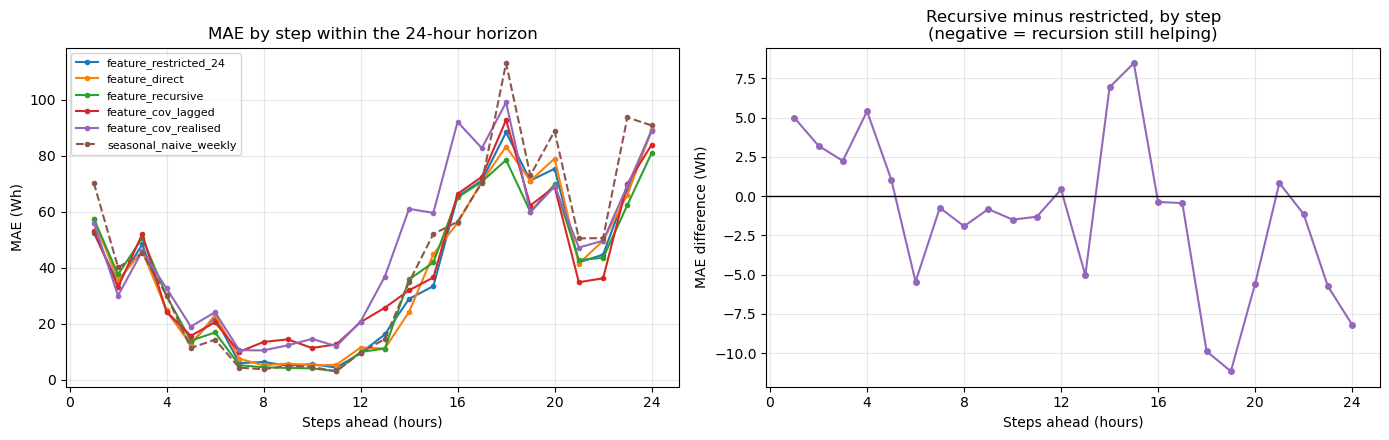

      feature_restricted_24  feature_direct  feature_recursive  feature_cov_lagged  feature_cov_realised  seasonal_naive_weekly
step                                                                                                                           
1                      52.5            57.5               57.5                53.1                  56.1                   70.4
6                      22.3            23.1               16.8                20.5                  24.1                   14.3
12                      9.5            11.5                9.9                20.6                  20.7                    9.6
18                     88.4            83.3               78.5                92.8                  99.0                  113.1
24                     89.1            89.1               81.0                83.9                  88.8                   90.8


In [39]:

# 16. Error growth across the horizon

step_index = pd.Series(
    np.tile(np.arange(1, HORIZON + 1), N_WINDOWS), index=test.index, name="step"
)

by_step = pd.DataFrame({
    name: (series - test).abs().groupby(step_index).mean()
    for name, series in forecasts.items()
})

by_step[BEST_BENCHMARK] = (
    (benchmark_rolling[BEST_BENCHMARK] - test).abs().groupby(step_index).mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for column in by_step.columns:
    style = "--" if column == BEST_BENCHMARK else "-"
    axes[0].plot(by_step.index, by_step[column], style, marker="o", markersize=3,
                 label=column)

axes[0].set_title("MAE by step within the 24-hour horizon")
axes[0].set_xlabel("Steps ahead (hours)")
axes[0].set_ylabel("MAE (Wh)")
axes[0].set_xticks(range(0, 25, 4))
axes[0].legend(fontsize=8)

recursive_by_step = by_step["feature_recursive"]
restricted_by_step = by_step["feature_restricted_24"]

axes[1].plot(by_step.index, recursive_by_step - restricted_by_step,
             marker="o", markersize=4, color="tab:purple")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Recursive minus restricted, by step\n(negative = recursion still helping)")
axes[1].set_xlabel("Steps ahead (hours)")
axes[1].set_ylabel("MAE difference (Wh)")
axes[1].set_xticks(range(0, 25, 4))

fig.tight_layout()
save_fig(fig, "05_error_by_horizon_step.png")

plt.show()

print(by_step.loc[[1, 6, 12, 18, 24]].round(1).to_string())

The by-step table contains a genuinely surprising result and it is worth building a
paragraph of the report around it.

**At step 1 - the 18:00 evening peak - the restricted model beats the models that are
allowed to see `lag_1`.** The direct and recursive strategies share the same one-step model
at step 1, and both are markedly worse there than a model whose most recent input is a day
old. Access to the immediately preceding observation makes the forecast *worse* at exactly
the hour that matters most.

The explanation is the amplitude volatility identified in notebook 02. At 17:00 the
household is often already ramping up, so `lag_1` is a strong but unreliable signal: the
model anchors on it and extrapolates the ramp, and when the evening turns out quiet it
overshoots badly. The restricted model, having only day-old information, falls back on the
typical shape for that hour and is wrong by less.

This is also why recursion does not pay here. Its supposed advantage is precisely the
recent lags, and those lags are least trustworthy at the point in the day where the errors
are largest.

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\05_feature_forecasts.png


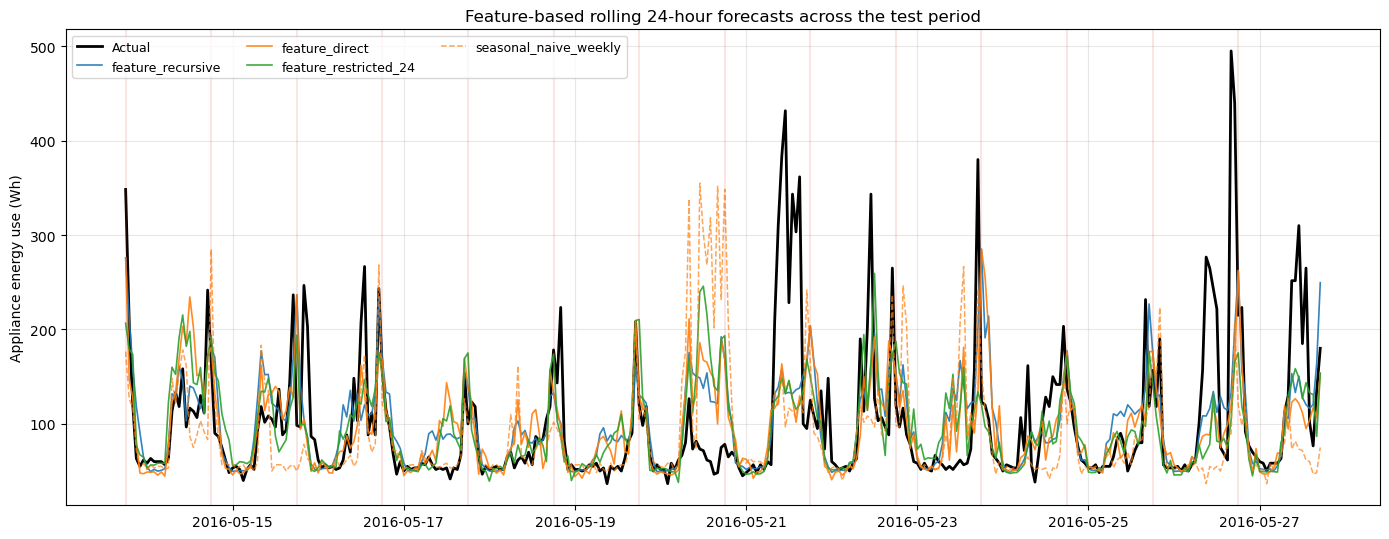

In [40]:

# 17. Forecasts across the test period

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.plot(test.index, test.values, color="black", linewidth=2, label="Actual")

for name in ["feature_recursive", "feature_direct", "feature_restricted_24"]:
    ax.plot(forecasts[name].index, forecasts[name].values, linewidth=1.2,
            alpha=0.9, label=name)

ax.plot(benchmark_rolling.index, benchmark_rolling[BEST_BENCHMARK],
        color="tab:orange", linewidth=1.1, alpha=0.7, linestyle="--",
        label=BEST_BENCHMARK)

for window in range(N_WINDOWS):
    ax.axvline(test.index[window * HORIZON], color="tab:red", alpha=0.12)

ax.set_title("Feature-based rolling 24-hour forecasts across the test period")
ax.set_ylabel("Appliance energy use (Wh)")
ax.legend(ncol=3, fontsize=9)

fig.tight_layout()
save_fig(fig, "05_feature_forecasts.png")

plt.show()

## 11. Feature importance

Built-in tree importances are biased towards high-cardinality features, so **permutation
importance** is used instead: each feature is shuffled in turn and the increase in error is
recorded. It is computed on the final 14 days of the *training* period - a validation block
the model was not fitted on - so that the test period stays untouched.

In [41]:

# 18. Permutation importance

validation_start = test.index[0] - pd.Timedelta(hours=TEST_STEPS)

validation_features = features_h24.loc[validation_start:test.index[0]].dropna()
validation_target = y.loc[validation_features.index]

# Refit without the validation block so importance is measured out of sample.
importance_model = fit_model(features_h24, y, end=validation_start, **BEST_PARAMS)

started = time.time()

importance = permutation_importance(
    importance_model,
    validation_features,
    validation_target,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)

importance_table = pd.DataFrame({
    "feature": validation_features.columns,
    "importance_MAE_increase": importance.importances_mean,
    "std": importance.importances_std,
}).sort_values("importance_MAE_increase", ascending=False).reset_index(drop=True)

importance_table.to_csv(METRICS_DIR / "feature_importance.csv", index=False)

print(f"Computed in {time.time() - started:.0f}s\n")
print(importance_table.head(15).round(3).to_string(index=False))

Computed in 9s

          feature  importance_MAE_increase   std
         hour_cos                    3.977 1.271
          lag_168                    2.900 0.455
same_hour_mean_7d                    2.575 0.770
          dow_sin                    2.220 0.224
           lag_24                    1.851 0.434
           lag_48                    1.257 0.466
      roll_mean_6                    0.934 0.614
           lag_25                    0.770 0.332
       roll_std_6                    0.496 0.251
          dow_cos                    0.486 0.410
      roll_mean_3                    0.382 0.163
             hour                    0.234 0.441
         hour_sin                    0.157 0.623
     roll_mean_24                    0.020 0.245
       is_weekend                    0.000 0.000


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\feature_importance.png


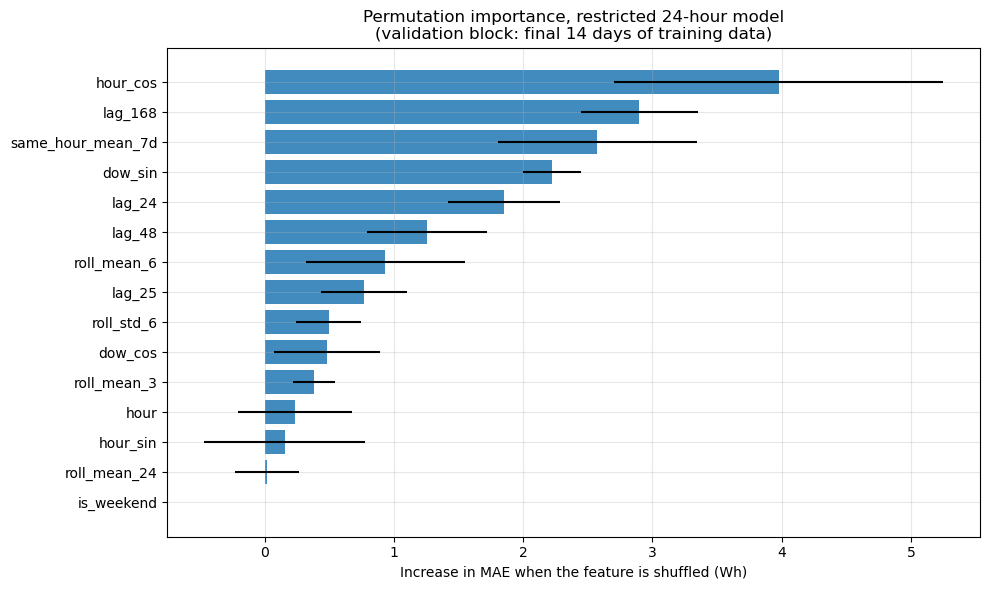

In [42]:

# 19. Plot feature importance

top = importance_table.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top["feature"], top["importance_MAE_increase"],
        xerr=top["std"], color="tab:blue", alpha=0.85)

ax.set_xlabel("Increase in MAE when the feature is shuffled (Wh)")
ax.set_title("Permutation importance, restricted 24-hour model\n"
             "(validation block: final 14 days of training data)")

fig.tight_layout()
save_fig(fig, "feature_importance.png")

plt.show()

Read this against the questions the brief asks. If the calendar and same-hour-average
features dominate while the sensor and weather features sit near zero, the model is
confirming what notebooks 02 and 04 found by other routes: appliance use is predictable
from *when it is* and from the household's recent typical level, and barely at all from the
environment. Three independent methods agreeing is a much stronger claim than any one of
them alone.

## 12. Save outputs

In [43]:

# 20. Save forecasts and metrics

feature_forecasts = pd.DataFrame({"actual": test})

for name, series in forecasts.items():
    feature_forecasts[name] = series

feature_forecasts["DIAGNOSTIC_1step_ahead"] = diagnostic_1step
feature_forecasts["window"] = np.repeat(np.arange(1, N_WINDOWS + 1), HORIZON)
feature_forecasts["step"] = step_index

feature_forecasts.to_csv(FORECAST_DIR / "feature_forecasts_rolling.csv")
feature_metrics.to_csv(METRICS_DIR / "feature_metrics_rolling.csv", index=False)

pd.Series(BEST_PARAMS).to_frame("value").to_csv(METRICS_DIR / "feature_hyperparameters.csv")

for path in sorted(FORECAST_DIR.glob("feature_*")) + sorted(METRICS_DIR.glob("feature_*")):
    print("Saved:", path.relative_to(PROJECT_ROOT))

Saved: outputs\forecasts\feature_forecasts_rolling.csv
Saved: outputs\metrics\feature_cv_results.csv
Saved: outputs\metrics\feature_hyperparameters.csv
Saved: outputs\metrics\feature_importance.csv
Saved: outputs\metrics\feature_metrics_rolling.csv


In [44]:

# 21. Checks on the saved outputs

reloaded = pd.read_csv(
    FORECAST_DIR / "feature_forecasts_rolling.csv", index_col=0, parse_dates=True
)

assert len(reloaded) == TEST_STEPS
assert reloaded.index.equals(test.index)
assert reloaded["window"].nunique() == N_WINDOWS
assert reloaded[list(forecasts.keys())].isna().sum().sum() == 0
assert "DIAGNOSTIC_1step_ahead" not in feature_metrics["model"].values, \
    "The one-step diagnostic must not appear in the model comparison"

print("Saved feature-model outputs verified:", len(reloaded), "rows,",
      reloaded["window"].nunique(), "windows.")

Saved feature-model outputs verified: 336 rows, 14 windows.
